In [1]:
import os, json, math
from datetime import datetime, timedelta
from dataclasses import dataclass, field, asdict
from typing import List, Dict, Optional
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
load_dotenv()

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

from langchain_openai import ChatOpenAI
llm = ChatOpenAI(model="gpt-4o-mini")


In [2]:
categories = {
    "국내주식": 145, "해외주식": 120, "채권": 85,
    "섹터": 95, "원자재": 25, "부동산": 15, "기타": 30,
}

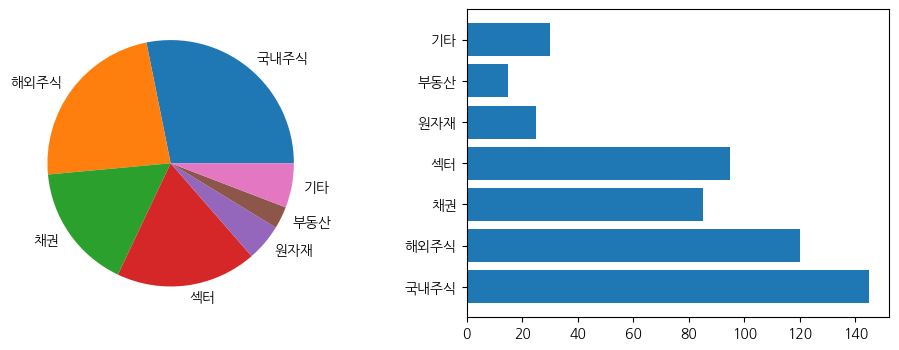

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.pie(categories.values(), labels = categories.keys(), )
ax2.barh(list(categories.keys()), list(categories.values()))

plt.show()

In [4]:
etf_universe = [
    {"name": "KODEX 200", "cat": "국내주식", "ret_1y": 12.3, "risk": 15.2},
    {"name": "TIGER S&P500", "cat": "해외주식", "ret_1y": 18.5, "risk": 13.8},
    {"name": "KODEX 배당가치", "cat": "배당", "ret_1y": 8.2, "risk": 10.5},
    {"name": "TIGER 반도체", "cat": "섹터", "ret_1y": 35.2, "risk": 28.4},
    {"name": "KODEX 국고채3년", "cat": "채권", "ret_1y": 3.5, "risk": 2.1},
    {"name": "KODEX 골드선물", "cat": "원자재", "ret_1y": 15.8, "risk": 16.3},
    {"name": "KODEX 2차전지", "cat": "섹터", "ret_1y": -5.2, "risk": 32.1},
    {"name": "TIGER 단기통안채", "cat": "채권", "ret_1y": 3.2, "risk": 0.8},
]


In [5]:
df_etf = pd.DataFrame(etf_universe)
df_etf

,name,cat,ret_1y,risk
0,KODEX 200,국내주식,12.3,15.2
1,TIGER S&P500,해외주식,18.5,13.8
2,KODEX 배당가치,배당,8.2,10.5
3,TIGER 반도체,섹터,35.2,28.4
4,KODEX 국고채3년,채권,3.5,2.1
5,KODEX 골드선물,원자재,15.8,16.3
6,KODEX 2차전지,섹터,-5.2,32.1
7,TIGER 단기통안채,채권,3.2,0.8


In [6]:
df_etf['cat'].unique()

array(['국내주식', '해외주식', '배당', '섹터', '채권', '원자재'], dtype=object)

In [7]:
for _, row in df_etf[df_etf['cat']=='채권'].iterrows():
    print(row)

name      KODEX 국고채3년
cat                채권
ret_1y            3.5
risk              2.1
Name: 4, dtype: object
name      TIGER 단기통안채
cat                채권
ret_1y            3.2
risk              0.8
Name: 7, dtype: object


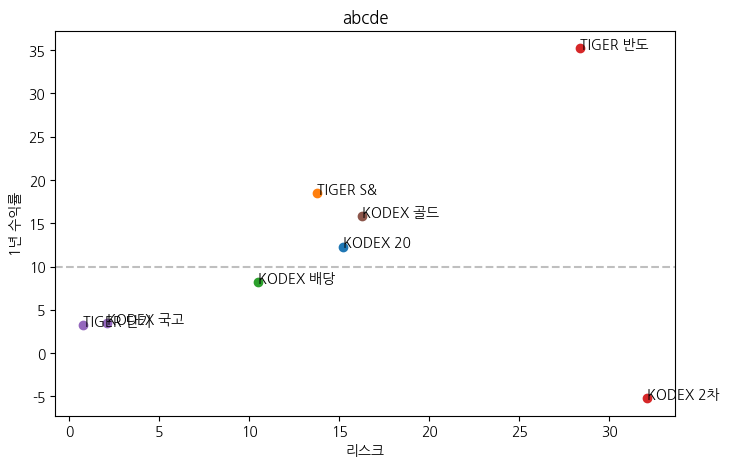

In [8]:
fig, ax = plt.subplots(figsize = (8,5))
for cat in df_etf['cat'].unique() :
    sub = df_etf[df_etf['cat']==cat]
    ax.scatter(sub['risk'], sub['ret_1y'], label = cat)
    for _, row in sub.iterrows():
        ax.annotate(row['name'][:8], (row['risk'], row['ret_1y']))

ax.set_xlabel('리스크')
ax.set_ylabel('1년 수익률')
ax.set_title('abcde')
ax.axhline(y=10, color='gray', linestyle='--', alpha=0.5)
plt.show()

In [9]:
# 데이터 스키마
# {"name": "KODEX 200", "cat": "국내주식", "ret_1y": 12.3, "risk": 15.2}
# {'국내 주식', "12.3%", 20 

# dataclass

In [10]:
@dataclass
class ETFSchema: # def __init__
    ticker : str  # 00233439
    name : str
    category : str
    expense_ratio : float
    risk_level : str = "중간"
    aum_billion : float = 0.0
    description : str = ""
    keywords : List[str] = field(default_factory=list)

    def __post_init__(self):
        if self.expense_ratio < 0 or self.expense_ratio > 5:
            raise ValueError(f"수수료 범위 오류: {self.expense_ratio}")
        valid_risks = ["매우낮음", "낮음", "중간", "높음", "매우높음"]
        if self.risk_level not in valid_risks:
            raise ValueError(f"리스크 등급 오류: {self.risk_level}")  # "매우 낮음"

In [11]:
etf = ETFSchema(
    ticker = "069500", name="KODEX 200", category="국내주식", expense_ratio=1.5, keywords = ['코스피', '대형주', '인덱스'])

In [12]:
etf

ETFSchema(ticker='069500', name='KODEX 200', category='국내주식', expense_ratio=1.5, risk_level='중간', aum_billion=0.0, description='', keywords=['코스피', '대형주', '인덱스'])

In [13]:
etf.ticker, etf.name, etf.expense_ratio

('069500', 'KODEX 200', 1.5)

In [14]:
etf_dict = asdict(etf)

In [15]:
etf_dict

{'ticker': '069500',
 'name': 'KODEX 200',
 'category': '국내주식',
 'expense_ratio': 1.5,
 'risk_level': '중간',
 'aum_billion': 0.0,
 'description': '',
 'keywords': ['코스피', '대형주', '인덱스']}

In [16]:
etf_json = json.dumps(etf_dict, ensure_ascii=False, indent=2)
etf_json

'{\n  "ticker": "069500",\n  "name": "KODEX 200",\n  "category": "국내주식",\n  "expense_ratio": 1.5,\n  "risk_level": "중간",\n  "aum_billion": 0.0,\n  "description": "",\n  "keywords": [\n    "코스피",\n    "대형주",\n    "인덱스"\n  ]\n}'

In [17]:
ETFSchema(**json.loads(etf_json))

ETFSchema(ticker='069500', name='KODEX 200', category='국내주식', expense_ratio=1.5, risk_level='중간', aum_billion=0.0, description='', keywords=['코스피', '대형주', '인덱스'])

In [18]:
test_cases = [
    {"ticker": "A", "name": "정상", "category": "채권",
     "expense_ratio": 0.05, "risk_level": "낮음"},
    {"ticker": "B", "name": "수수료오류", "category": "주식",
     "expense_ratio": -0.5, "risk_level": "중간"},
    {"ticker": "C", "name": "리스크오류", "category": "원자재",
     "expense_ratio": 0.3, "risk_level": "최고"},
]

In [19]:
for tc in test_cases:
    try:
        e = ETFSchema(**tc)
        print(f" {tc['name']}: 생성 성공")
    except ValueError as err:
        print(f" {tc['name']} : {err}")

 정상: 생성 성공
 수수료오류 : 수수료 범위 오류: -0.5
 리스크오류 : 리스크 등급 오류: 최고


In [20]:
# ETFReturns : 데이터 스키마
# __post_init__ 수익률 유효성 검증 (-100% ~ 500%)
# ticker : str
# return_1m : float
# return_3m : float
# return_1y : float
# return_3y : float

SyntaxError: invalid syntax (3505611731.py, line 1)

In [21]:
@dataclass
class ETFReturns:
    ticker : str
    return_1m : float
    return_3m : float
    return_1y : float
    return_3y : float

    def __post_init__(self):
        # if self.return_1m < -100 or self.return_1m > 500:
        #     raise ValueError(f"rate 범위 오류: {self.return_1m}")
        # if self.return_3m < -100 or self.return_3m > 500:
        #     raise ValueError(f"rate 범위 오류: {self.return_1m}")
        # if self.return_1y < -100 or self.return_1y > 500:
        #     raise ValueError(f"rate 범위 오류: {self.return_1m}")
        # if getattr(self, 'return_1m') < -100 or getattr(self, 'return_1m') > 500:  # self.return_1m
        #     raise ValueError(f"rate 범위 오류: {self.return_1m}")
        for field_name in ['return_1m', 'return_3m', 'return_1y', 'return_3y']:
            value = getattr(self, field_name)
            if value < -100 or value > 500:
                raise ValueError(f"{field_name} 오류: {value}")

In [22]:
ETFReturns("123456", -200.1, 5.4, 12.3, 28.5)

ValueError: return_1m 오류: -200.1

In [23]:
# FinanceDataReader

In [24]:
# !pip install finance-datareader

In [25]:
# StockListing('ETF/KR')
# DataReader('123456', start, end)

In [26]:
import FinanceDataReader as fdr

In [27]:
etf_list = fdr.StockListing('ETF/KR')

In [28]:
len(etf_list)

1088

In [29]:
etf_list.head(3)

,Symbol,Category,Name,Price,RiseFall,Change,ChangeRate,NAV,EarningRate,Volume,Amount,MarCap
0,069500,1,KODEX 200,90430,2,2550,2.90,90560.0,28.4924,14863983,1351020,207537
1,360750,4,TIGER 미국S&P500,25330,2,265,1.06,25291.0,-1.5438,10867442,275477,156881
2,396500,2,TIGER 반도체TOP10,34600,2,850,2.52,34824.0,45.4427,16138341,561843,94994


In [30]:
ticker = "069500"
end_date = datetime.now().strftime('%Y-%m-%d')
start_date = (datetime.now() - timedelta(days=365)).strftime('%Y-%m-%d')

end_date, start_date

('2026-04-14', '2025-04-14')

In [31]:
price_df = fdr.DataReader(ticker, start_date, end_date)

In [32]:
len(price_df)

244

In [33]:
def collect_etf_price(ticker, days=365):
    end_date = datetime.now().strftime('%Y-%m-%d')
    start_date = (datetime.now() - timedelta(days=days)).strftime('%Y-%m-%d')

    try:
        df = fdr.DataReader(ticker, start_date, end_date)
        if len(df) > 0:
            return {'status' : 'real', 'data' : df, 'ticker' : ticker}
    except Exception:
        pass

In [34]:
tickers = ['069500']
collect_etf_price(tickers[0])

{'status': 'real',
 'data':              Open   High    Low  Close    Volume    Change
 Date                                                      
 2025-04-14  32343  32570  32271  32373   5621869  0.006342
 2025-04-15  32417  32781  32417  32692   8915848  0.009854
 2025-04-16  32556  32614  32169  32183   7177604 -0.015570
 2025-04-17  32271  32561  32203  32501   6951765  0.009881
 2025-04-18  32556  32722  32452  32722   6025639  0.006800
 ...           ...    ...    ...    ...       ...       ...
 2026-04-08  87850  90070  87400  89000  29329013  0.075269
 2026-04-09  88310  88735  87070  87250  20553049 -0.019663
 2026-04-10  88795  89805  88520  88655  12112242  0.016103
 2026-04-13  86465  88090  86410  87880  13658534 -0.008742
 2026-04-14  90245  91600  89955  90430  14863983  0.029017
 
 [244 rows x 6 columns],
 'ticker': '069500'}

In [ ]:
# 결측치 처리, 이상치 처리

In [ ]:
# # 주말, 휴장일, : row 전체가 결측치  / row 일부가 결측치
# 1. 무시 : 결측치 있는 값을 지워버린다
# 2. 채운다 : 

In [ ]:
# 4/14 : 32570
# 4/15 :  채워준다. : interpolation : 평균 / 이전일 또는 이후일의 값 / rolling-average
# 4/16 : 32614

In [ ]:
# outlier , anomaly , 이상치
# IQR : anomaly detect -> 지워버리거나 / 

In [36]:
sample_df = price_df.copy()

In [43]:
mask = np.random.random(len(sample_df)) < 0.05

In [44]:
sample_df.loc[mask, 'Close'] = np.nan

In [47]:
sample_df['Close'].isna().sum()

np.int64(14)

In [48]:
len(sample_df)

244

In [49]:
ffill_df = sample_df.copy()
ffill_df['Close'] = ffill_df['Close'].ffill()

In [50]:
ffill_df['Close'].isna().sum()

np.int64(0)

In [51]:
interp_df = sample_df.copy()
interp_df['Close'].isna().sum()

np.int64(14)

In [52]:
interp_df['Close'] = interp_df['Close'].interpolate(method='linear')

In [53]:
interp_df['Close'].isna().sum()

np.int64(0)

In [55]:
rolling_df['Close'].head()

Date
2025-04-14    32373.0
2025-04-15    32692.0
2025-04-16    32183.0
2025-04-17    32501.0
2025-04-18    32722.0
Name: Close, dtype: float64

In [56]:
rolling_df = sample_df.copy()
rolling_mean = rolling_df['Close'].rolling(5, min_periods=1).mean()
rolling_mean
rolling_df['Close'] = rolling_df['Close'].fillna(rolling_mean)

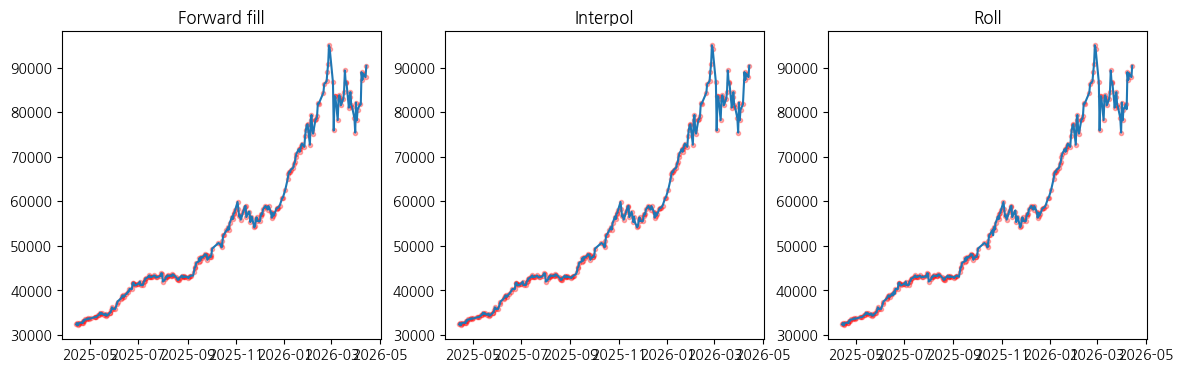

In [59]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, df_filled, title in zip(axes, [ffill_df,interp_df, rolling_df], ['Forward fill', 'Interpol', 'Roll']):
    ax.plot(sample_df.index, sample_df['Close'], 'ro', markersize=3, alpha=0.3, label='missing')
    ax.plot(df_filled.index, df_filled['Close'], label=title)
    ax.set_title(title)
plt.show()

In [64]:
def detect_iqr(series, factor=1.5):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return (series < q1 - factor * iqr) | (series > q3 + factor * iqr)

def detect_z(series, threshold=3.0):
    z = (series - series.mean()) / series.std()
    return z.abs() > threshold


z_outliers = detect_z(ffill_df)
z_outliers.sum()

Open      0
High      0
Low       0
Close     0
Volume    3
Change    7
dtype: int64

In [65]:
iqr_outliers = detect_iqr(ffill_df)
iqr_outliers.sum()

Open       0
High       0
Low        0
Close      0
Volume    10
Change    23
dtype: int64

In [66]:
(z_outliers & iqr_outliers).sum()

Open      0
High      0
Low       0
Close     0
Volume    3
Change    7
dtype: int64

In [67]:
ffill_df.head()

,Open,High,Low,Close,Volume,Change
Date,,,,,,
2025-04-14,32343,32570,32271,32373.0,5621869,0.006342
2025-04-15,32417,32781,32417,32692.0,8915848,0.009854
2025-04-16,32556,32614,32169,32183.0,7177604,-0.015570
2025-04-17,32271,32561,32203,32501.0,6951765,0.009881
2025-04-18,32556,32722,32452,32722.0,6025639,0.006800


In [68]:
features = ffill_df[['Close']].copy()

In [69]:
features

,Close
Date,
2025-04-14,32373.0
2025-04-15,32692.0
2025-04-16,32183.0
2025-04-17,32501.0
2025-04-18,32722.0
...,...
2026-04-08,89000.0
2026-04-09,87250.0
2026-04-10,88655.0


In [70]:
features['return'] = features['Close'].pct_change()

In [71]:
features.head()

,Close,return
Date,,
2025-04-14,32373.0,NaN
2025-04-15,32692.0,0.009854
2025-04-16,32183.0,-0.015570
2025-04-17,32501.0,0.009881
2025-04-18,32722.0,0.006800


In [75]:
features['vol_5d'] = features['return'].rolling(5).std()
features['vol_20d'] = features['return'].rolling(20).std()

In [73]:
features.head()

,Close,return,vol_5d
Date,,,
2025-04-14,32373.0,NaN,NaN
2025-04-15,32692.0,0.009854,NaN
2025-04-16,32183.0,-0.015570,NaN
2025-04-17,32501.0,0.009881,NaN
2025-04-18,32722.0,0.006800,NaN


In [77]:
features['log_return'] = np.log(features['Close'] / features['Close'].shift(1))

In [80]:
def preprocess_pipeline(df):
    result = df[['Close']].copy()

    #1. 결측값을 처리 (linear- interpolation)
    result['Close'] = result['Close'].interpolate(method='linear')
    result['Close'] = result['Close'].ffill().bfill()

    #2. 이상치를 ffill (IQR * 1.5)
    ret = result['Close']
    q1, q3 = ret.quantile(0.25), ret.quantile(0.75)
    iqr = q3 - q1
    outlier_mask  = (ret < q1 - 1.5 * iqr) | (ret > q3 + 1.5 * iqr)
    result.loc[outlier_mask, 'Close'] = np.nan
    result['Close'] = result['Close'].ffill()

    #3. feature 추가 (return, log_return)
    result['return'] = result['Close'].pct_change()
    result['log_return'] = np.log(features['Close'] / features['Close'].shift(1))

    return result
    

In [81]:
processed = preprocess_pipeline(price_df)

In [82]:
processed.head()

,Close,return,log_return
Date,,,
2025-04-14,32373.0,NaN,NaN
2025-04-15,32692.0,0.009854,0.009806
2025-04-16,32183.0,-0.015570,-0.015692
2025-04-17,32501.0,0.009881,0.009832
2025-04-18,32722.0,0.006800,0.006777


In [ ]:
# 이동평균, 트렌드 분해(decomposition), 이상 탐지, 분포 분석
# 서버 트래픽, 이커머스 구매내역, 센서 데이터, 온도,,,,,

In [ ]:
# 이동평균 : 노이즈
# S(standard)MA : 최근 N개의 평균
# E(exponential)MA : 최근 값에 더 큰 가중치를 두는 MA

In [ ]:
트렌드 분해(decomposition)
트렌드 : 장기적으로 매출이 상승하고 있다. 전반적으로 시니어 타겟의 시장이 커지고 있다.
Seasonality (주기) : 여름에는 잘팔리고, 겨울에는 안팔린다
Residual (잔차) : 나머지